In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("Online Retail.xlsx")

print(df)


       InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

               InvoiceDate  UnitPrice  CustomerID         Country  
0      

In [4]:
print(df.shape)
print(df.dtypes)
print(df.describe())
print(df.isnull().sum())
print(df.duplicated())
print(df.bfill())

(541909, 8)
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object
            Quantity                 InvoiceDate      UnitPrice     CustomerID
count  541909.000000                      541909  541909.000000  406829.000000
mean        9.552250  2011-07-04 13:34:57.156386       4.611114   15287.690570
min    -80995.000000         2010-12-01 08:26:00  -11062.060000   12346.000000
25%         1.000000         2011-03-28 11:34:00       1.250000   13953.000000
50%         3.000000         2011-07-19 17:17:00       2.080000   15152.000000
75%        10.000000         2011-10-19 11:27:00       4.130000   16791.000000
max     80995.000000         2011-12-09 12:50:00   38970.000000   18287.000000
std       218.081158                         NaN      96.759853    1713.600303
InvoiceNo           0
S

In [5]:
print(df.isnull().sum())
print(df.bfill)

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
<bound method NDFrame.bfill of        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    

In [9]:
print(df.isnull().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [10]:
df["Description"] = df["Description"].bfill()

In [11]:
df["CustomerID"] = df["CustomerID"].bfill()

In [6]:
print(df.isnull().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


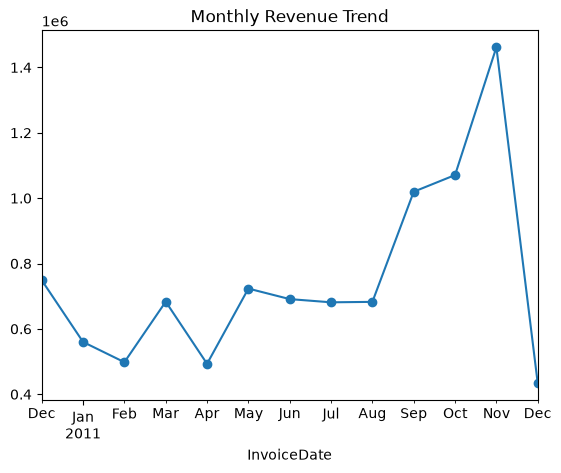

In [8]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Revenue'] = df['Quantity'] * df['UnitPrice']

monthly_sales = df.groupby(df['InvoiceDate'].dt.to_period('M'))['Revenue'].sum()
monthly_sales.plot(kind='line', marker='o', title='Monthly Revenue Trend')
plt.show()

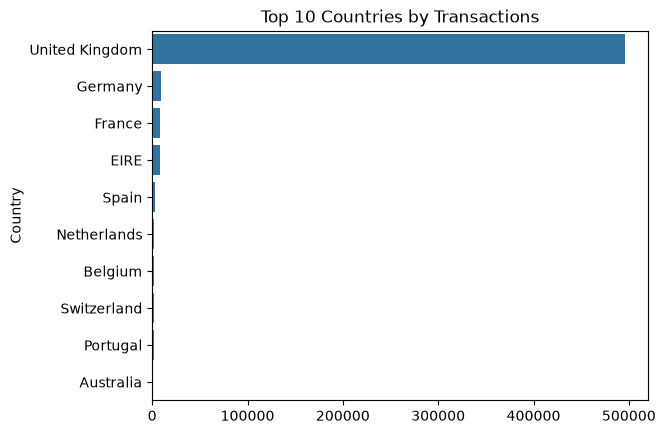

In [9]:
country_counts = df['Country'].value_counts().head(10)
sns.barplot(x=country_counts.values, y=country_counts.index)
plt.title('Top 10 Countries by Transactions')
plt.show()

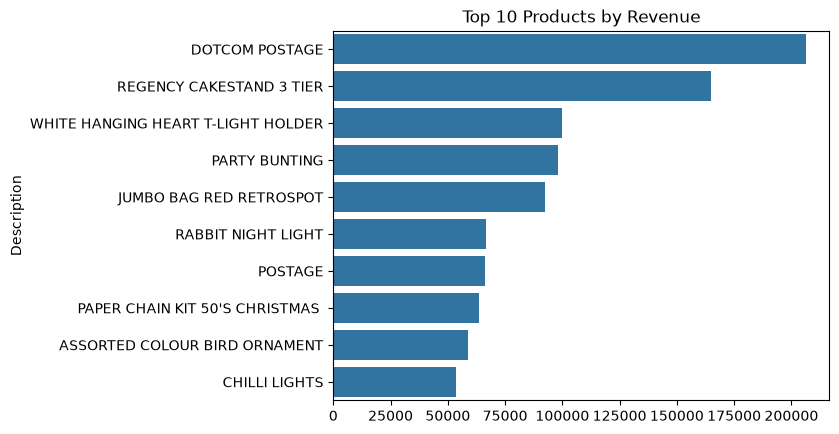

In [10]:
top_rev = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_rev.values, y=top_rev.index)
plt.title('Top 10 Products by Revenue')
plt.show()

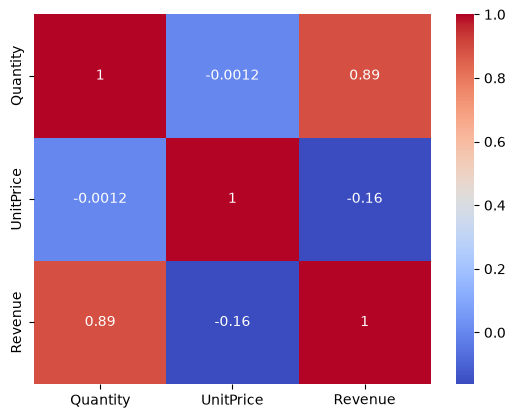

In [11]:
corr = df[['Quantity', 'UnitPrice', 'Revenue']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

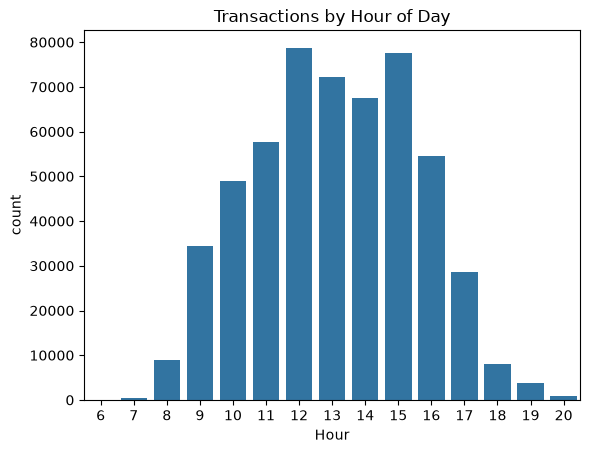

In [12]:
df['Hour'] = df['InvoiceDate'].dt.hour
sns.countplot(x='Hour', data=df)
plt.title('Transactions by Hour of Day')
plt.show()